In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# ==========================================
# 1. 환경 설정 (Configuration)
# ==========================================
class Config:
    # 분석 및 학습에 사용할 데이터 소스 경로
    DATA_SOURCES = {
        'S&P 500': max(glob.glob('./SnP500_*.csv'), key=os.path.getctime) if glob.glob('./SnP500_*.csv') else './SnP500_60years_daily.csv',
        'Nasdaq 100': max(glob.glob('./Nasdaq100_*.csv'), key=os.path.getctime) if glob.glob('./Nasdaq100_*.csv') else './Nasdaq100_60years_daily.csv'
    }
    WINDOW_SIZE = 5      # 과거 며칠간의 데이터를 특징(Feature)으로 사용할지 설정
    THRESHOLD = 0.002    # '상승'으로 판단할 수익률 임계값 (0.2% 이상 시 1, 미만 시 0)
    TRAIN_SPLIT = 0.8    # 전체 데이터 중 학습에 사용할 비율 (80% 학습, 20% 테스트)

# ==========================================
# 2. 데이터 처리 클래스 (Data Processing)
# ==========================================
class DataProcessor:
    """데이터 로딩, 고급 기술적 지표 계산 및 피처 스케일링 수행"""
    def __init__(self, file_path):
        self.file_path = file_path
        self.features = []
        from sklearn.preprocessing import StandardScaler
        self.scaler = StandardScaler()

    def load_and_clean(self):
        """CSV 로드 및 기본 전처리 (날짜 정렬 및 수치형 변환)"""
        import pandas as pd
        df = pd.read_csv(self.file_path)
        df.columns = [c.lower() for c in df.columns]
        df = df.sort_values(by='date').reset_index(drop=True)
        cols = ['open', 'high', 'low', 'close', 'volume']
        df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
        return df

    def add_features(self, df):
        """학술 연구용 고급 보조지표 및 Lag 데이터 생성"""
        import pandas as pd
        import numpy as np
        
        # 기본 변동성 지표
        df['return'] = df['close'].pct_change()
        df['vol_change'] = df['volume'].pct_change()
        df['high_low_gap'] = (df['high'] - df['low']) / df['open']

        # RSI
        delta = df['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(window=14).mean()
        loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # MACD & Histogram
        exp1 = df['close'].ewm(span=12, adjust=False).mean()
        exp2 = df['close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = (exp1 - exp2) / df['close'] 
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

        # Bollinger Bands & Pct
        df['MA20'] = df['close'].rolling(window=20).mean()
        df['std20'] = df['close'].rolling(window=20).std()
        df['BB_Upper'] = df['MA20'] + (df['std20'] * 2)
        df['BB_Lower'] = df['MA20'] - (df['std20'] * 2)
        df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['MA20']
        
        # Stochastic
        low_min = df['low'].rolling(window=14).min()
        high_max = df['high'].rolling(window=14).max()
        df['Stochastic_K'] = 100 * (df['close'] - low_min) / (high_max - low_min)
        df['Stochastic_D'] = df['Stochastic_K'].rolling(window=3).mean()

        # ATR
        tr = pd.concat([df['high'] - df['low'],
                        abs(df['high'] - df['close'].shift()),
                        abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
        df['ATR'] = tr.rolling(window=14).mean() / df['close']

        # Exponential Moving Averages (EMA)
        for span in [5, 10, 20, 50]:
            df[f'EMA_{span}'] = df['close'].ewm(span=span, adjust=False).mean() / df['close']

        # Williams %R
        df['Williams_R'] = (high_max - df['close']) / (high_max - low_min) * -100
        
        # Rate of Change (ROC)
        df['ROC_10'] = df['close'].pct_change(periods=10)
        df['ROC_20'] = df['close'].pct_change(periods=20)

        # 시차(Lag) 피처
        lag_features = {}
        for i in range(1, Config.WINDOW_SIZE + 1):
            lag_features[f'return_lag_{i}'] = df['return'].shift(i)
            lag_features[f'vol_lag_{i}'] = df['vol_change'].shift(i)
        
        df = pd.concat([df, pd.DataFrame(lag_features)], axis=1)

        self.features = ['return', 'vol_change', 'high_low_gap', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
                        'BB_Width', 'Stochastic_K', 'Stochastic_D', 'ATR', 'Williams_R', 'ROC_10', 'ROC_20'] + \
                        [f'EMA_{s}' for s in [5, 10, 20, 50]] + \
                        [f'return_lag_{i}' for i in range(1, Config.WINDOW_SIZE + 1)] + \
                        [f'vol_lag_{i}' for i in range(1, Config.WINDOW_SIZE + 1)]

        df['target'] = (df['return'].shift(-1) > Config.THRESHOLD).astype(int)
        df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
        return df

    def split_data(self, df):
        """데이터 분리 및 스케일링(Scaling)"""
        import pandas as pd
        X = df[self.features]
        y = df['target']
        split_idx = int(len(df) * Config.TRAIN_SPLIT)
        
        X_train_raw = X[:split_idx]
        X_test_raw = X[split_idx:]
        
        # 스케일링 (Data Leakage 방지를 위해 Train 데이터로만 fit)
        X_train_scaled = self.scaler.fit_transform(X_train_raw)
        X_test_scaled = self.scaler.transform(X_test_raw)
        
        # Feature Importance 유지를 위해 DataFrame 복원
        X_train = pd.DataFrame(X_train_scaled, columns=self.features, index=X_train_raw.index)
        X_test = pd.DataFrame(X_test_scaled, columns=self.features, index=X_test_raw.index)
        
        y_train = y[:split_idx]
        y_test = y[split_idx:]
        
        df_test = df.iloc[split_idx:].copy()
        df_test['Next_Return'] = df_test['return'].shift(-1).fillna(0)
        
        return X_train, X_test, y_train, y_test, df_test

class ModelManager:
    """연구 목적을 위한 TimeSeriesSplit 최적화, 스케일링 기반 다양한 앙상블 학습 모델링"""
    def __init__(self):
        from lightgbm import LGBMClassifier
        from sklearn.ensemble import VotingClassifier, RandomForestClassifier
        from xgboost import XGBClassifier
        from sklearn.linear_model import LogisticRegression

        # 스케일링이 적용되었으므로 선형 모델(LogisticRegression) 추가 가능
        self.base_xgb = XGBClassifier(random_state=42)
        self.base_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
        self.base_lgbm = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
        self.base_lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
        
        self.models = {}

    def train_and_predict(self, X_train, y_train, X_test, y_test):
        import numpy as np
        from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
        from sklearn.metrics import accuracy_score, classification_report, f1_score
        from sklearn.ensemble import VotingClassifier

        print("\n[TimeSeriesSplit 기반 하이퍼파라미터 최적화 시작 (Data Leakage 완전 차단 모드)]")
        tscv = TimeSeriesSplit(n_splits=3)
        
        xgb_params = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.03, 0.05],
            'max_depth': [3, 4, 5],
            'subsample': [0.8],
            'colsample_bytree': [0.8]
        }
        
        rf_params = {
            'n_estimators': [100, 200],
            'max_depth': [5, 7, 10],
            'min_samples_split': [2, 5]
        }
        
        lgbm_params = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.03, 0.05],
            'max_depth': [3, 4, 5]
        }
        
        lr_params = {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
        
        # XGB 클래스 불균형 보정
        neg_count = sum(y_train == 0)
        pos_count = sum(y_train == 1)
        scale_pos = neg_count / pos_count if pos_count > 0 else 1.0
        self.base_xgb.set_params(scale_pos_weight=scale_pos)
        
        # Time-Decay Sample Weights (최근 데이터일수록 가중치 부여)
        # 0.1 ~ 1.0 범위로 선형적으로 증가 (오래된 데이터는 영향력 축소)
        sample_weights = np.linspace(0.1, 1.0, len(y_train))
        
        print(" -> 최적의 파라미터를 탐색 중입니다... (1~2분 소요)")
        search_xgb = RandomizedSearchCV(self.base_xgb, xgb_params, n_iter=5, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        search_rf = RandomizedSearchCV(self.base_rf, rf_params, n_iter=5, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        search_lgbm = RandomizedSearchCV(self.base_lgbm, lgbm_params, n_iter=5, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        search_lr = RandomizedSearchCV(self.base_lr, lr_params, n_iter=4, cv=tscv, scoring='f1_macro', n_jobs=-1, random_state=42)
        
        # SearchCV fit은 일부 모델에서 sample_weight를 지원하지 않을 수 있으므로, 
        # 최적 파라미터 획득 후 최종 fit 과정에서만 sample_weight 적용합니다.
        search_xgb.fit(X_train, y_train)
        search_rf.fit(X_train, y_train)
        search_lgbm.fit(X_train, y_train)
        search_lr.fit(X_train, y_train)
        
        best_xgb = search_xgb.best_estimator_
        best_rf = search_rf.best_estimator_
        best_lgbm = search_lgbm.best_estimator_
        best_lr = search_lr.best_estimator_
        
        ensemble = VotingClassifier(estimators=[('XGB', best_xgb), ('RF', best_rf), ('LGBM', best_lgbm), ('LR', best_lr)], voting='soft')
        
        self.models = {
            'XGB': best_xgb,
            'RF': best_rf,
            'LGBM': best_lgbm,
            'LR': best_lr,
            'Ensemble': ensemble
        }
        
        for name, model in self.models.items():
            print(f"\n[{name} 모델 평가]")
            # 최종 학습에 Time-Decay 가중치 적용 (일부 모델 미지원 예외 처리)
            try:
                model.fit(X_train, y_train, sample_weight=sample_weights)
            except TypeError:
                try:
                    # Ensemble의 경우 fit_params로 전달 필요할 수 있음
                    model.fit(X_train, y_train, XGB__sample_weight=sample_weights, RF__sample_weight=sample_weights, LGBM__sample_weight=sample_weights, LR__sample_weight=sample_weights)
                except Exception:
                    # 완벽하게 호환되지 않는 경우 일반 학습 진행
                    model.fit(X_train, y_train)
            
            # [수정] Test Set Snooping Bias 방지: 최적 임계값은 오직 Train Set 내부에서만 탐색!
            probs_train = model.predict_proba(X_train)[:, 1]
            best_thresh = 0.5
            best_f1 = 0
            for th in np.arange(0.40, 0.60, 0.01):
                preds_train = (probs_train > th).astype(int)
                f1 = f1_score(y_train, preds_train, average='macro')
                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = th
            
            # 확정된(Blind) 임계값을 Test Set에 적용 (Real Out-of-Sample Evaluation)
            probs_test = model.predict_proba(X_test)[:, 1]
            final_preds = (probs_test > best_thresh).astype(int)
            acc = accuracy_score(y_test, final_preds)
            macro_f1 = f1_score(y_test, final_preds, average='macro')
            
            print(f" - Train 기준 최적 Threshold: {best_thresh:.2f} (Test 누수 없음)")
            print(f" - Out-of-Sample Accuracy: {acc:.4f}")
            print(f" - Out-of-Sample Macro F1: {macro_f1:.4f}")
            print(classification_report(y_test, final_preds))

if __name__ == "__main__":
    for asset_name, path in Config.DATA_SOURCES.items():
        if not os.path.exists(path):
            print(f"❌ 파일을 찾을 수 없습니다: {path}")
            continue

        print(f"\n🚀 {asset_name} 파이프라인 시작...")
        processor = DataProcessor(path)
        raw_df = processor.load_and_clean()
        processed_df = processor.add_features(raw_df)
        X_train, X_test, y_train, y_test, df_test = processor.split_data(processed_df)
        model_manager = ModelManager()
        model_manager.train_and_predict(X_train, y_train, X_test, y_test)
        print(f"✅ {asset_name} 파이프라인 완료\n" + "="*50)



🚀 S&P 500 파이프라인 시작...

[TimeSeriesSplit 기반 하이퍼파라미터 최적화 시작 (Data Leakage 완전 차단 모드)]
 -> 최적의 파라미터를 탐색 중입니다... (1~2분 소요)

[XGB 모델 평가]
 - Train 기준 최적 Threshold: 0.52 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5683
 - Out-of-Sample Macro F1: 0.5370
              precision    recall  f1-score   support

           0       0.61      0.71      0.66      1958
           1       0.47      0.37      0.42      1389

    accuracy                           0.57      3347
   macro avg       0.54      0.54      0.54      3347
weighted avg       0.56      0.57      0.56      3347


[RF 모델 평가]
 - Train 기준 최적 Threshold: 0.52 (Test 누수 없음)
 - Out-of-Sample Accuracy: 0.5722
 - Out-of-Sample Macro F1: 0.5332
              precision    recall  f1-score   support

           0       0.61      0.74      0.67      1958
           1       0.48      0.34      0.40      1389

    accuracy                           0.57      3347
   macro avg       0.54      0.54      0.53      3347
weighted avg       0.56      0.57


📊 Nasdaq 100 모델 피처 중요도 분석:


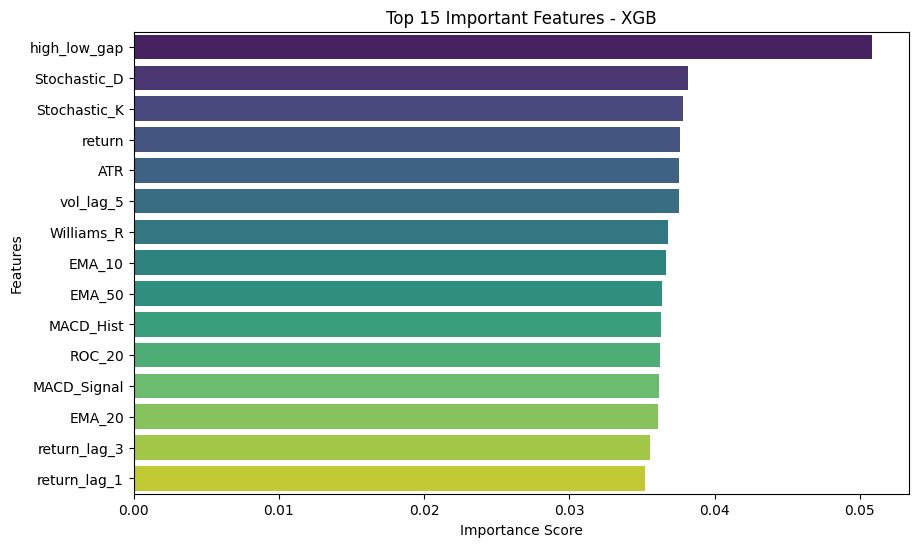

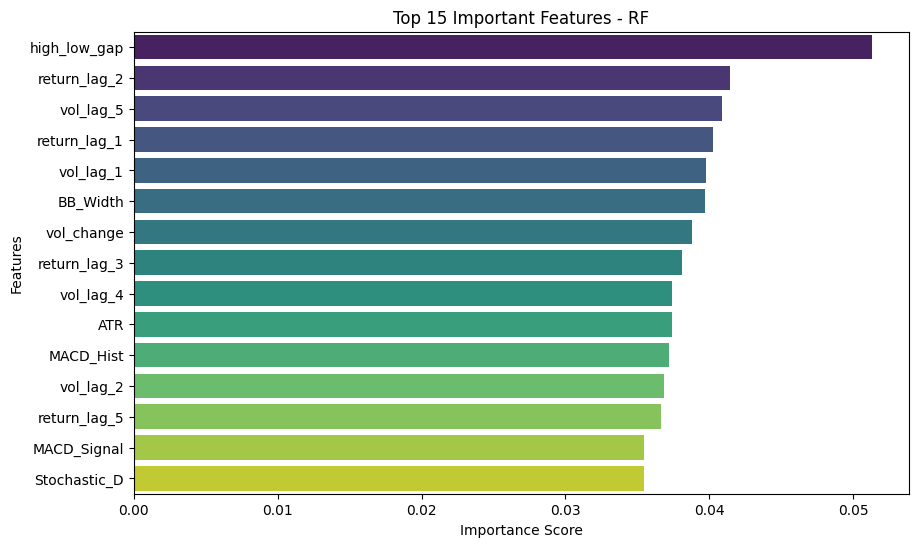

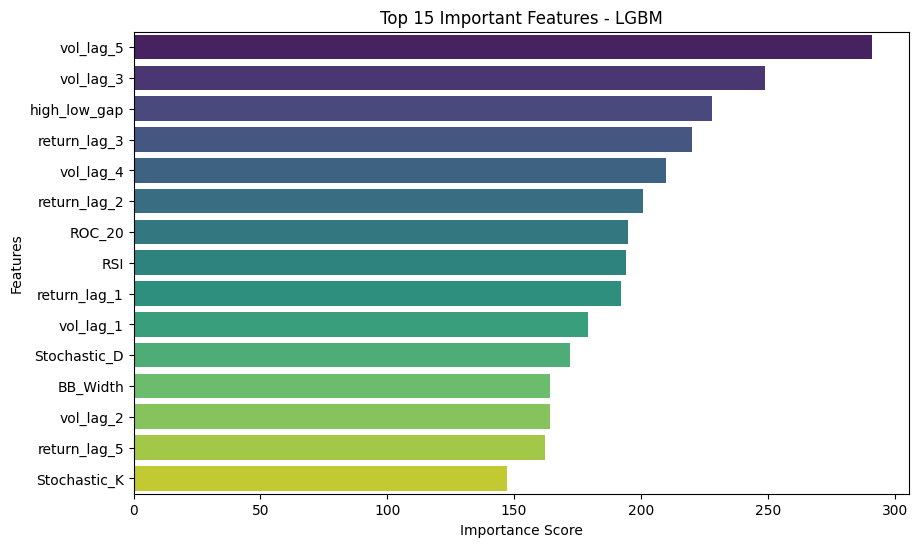


⚠️ LR 모델은 피처 중요도를 제공하지 않아 시각화를 생략합니다.

⚠️ Ensemble 모델은 피처 중요도를 제공하지 않아 시각화를 생략합니다.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importance(model_manager, features):
    """학습된 모델들의 피처 중요도를 시각화합니다."""
    for name, model in model_manager.models.items():
        if not hasattr(model, 'feature_importances_'):
            print(f"\n⚠️ {name} 모델은 피처 중요도를 제공하지 않아 시각화를 생략합니다.")
            continue
            
        importance = model.feature_importances_
        feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
        feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis', hue='Feature', legend=False)
        plt.title(f'Top 15 Important Features - {name}')
        plt.xlabel('Importance Score')
        plt.ylabel('Features')
        plt.show()

# 마지막으로 분석된 자산의 모델 정보를 바탕으로 중요도 출력
print(f"\n📊 {asset_name} 모델 피처 중요도 분석:")
plot_feature_importance(model_manager, processor.features)


In [3]:
from datetime import datetime, timedelta

def get_next_day_prediction(asset_name, processor, model_manager):
    """가장 최근 데이터를 바탕으로 내일의 주가 상승/하락 예측 결과 제공"""
    # 1. 가장 최근(마지막 행) 데이터 추출
    last_row_features = X_test.iloc[[-1]]
    last_row_full = df_test.iloc[-1]

    # 날짜 처리 (YYYYMMDD 숫자를 날짜 객체로 변환)
    last_date_str = str(int(last_row_full['date']))
    last_date_obj = datetime.strptime(last_date_str, '%Y%m%d')
    # 다음 거래일 계산
    next_date_obj = last_date_obj + timedelta(days=1)

    # 2. 모델별 예측 (1: 상승, 0: 하락/보합)
    predictions = {}
    for name, model in model_manager.models.items():
        pred = model.predict(last_row_features)[0]
        prob = model.predict_proba(last_row_features)[0][1] # 상승 확률
        predictions[name] = {'signal': pred, 'prob': prob}

    # 3. 결과 리포트 출력
    print(f"\n{'='*60}")
    print(f" 📈 [ {asset_name} - AI 주가 예측 리포트 ] ")
    print(f"{'='*60}")
    print(f" 📅 [1] 데이터 기준 거래일  : {last_date_obj.strftime('%Y-%m-%d')}")
    print(f" 🎯 [2] 예측 대상 목표일    : {next_date_obj.strftime('%Y-%m-%d')} (익일)")
    print(f"{'='*60}")

    print(f"[AI 모델별 분석 결과]")
    for name, res in predictions.items():
        direction = "상승 우세 ↑" if res['signal'] == 1 else "하락/보합 우세 ↓"
        print(f" - {name:<4}: {direction} (상승 확률: {res['prob']*100:.1f}%)")

    print(f"\n[종합 의견]")
    # 두 모델의 평균 확률 계산
    avg_prob = sum(res['prob'] for res in predictions.values()) / len(predictions)
    if avg_prob >= 0.6:
        opinion = "상승 가능성이 높습니다. 긍정적인 관점을 유지하세요."
    elif avg_prob >= 0.45:
        opinion = "방향성이 모호합니다. 시장 상황을 좀 더 관망하세요."
    else:
        opinion = "하락 또는 보합 가능성이 높으므로 주의가 필요합니다."

    print(f" ➔ {opinion}")
    print(f"{'='*60}")

# Nasdaq 100 기준으로 예측 실행 (backtester 인자 제거)
get_next_day_prediction("Nasdaq 100", processor, model_manager)


 📈 [ Nasdaq 100 - AI 주가 예측 리포트 ] 
 📅 [1] 데이터 기준 거래일  : 2026-08-10
 🎯 [2] 예측 대상 목표일    : 2026-08-11 (익일)
[AI 모델별 분석 결과]
 - XGB : 하락/보합 우세 ↓ (상승 확률: 44.7%)
 - RF  : 하락/보합 우세 ↓ (상승 확률: 44.5%)
 - LGBM: 하락/보합 우세 ↓ (상승 확률: 39.4%)
 - LR  : 하락/보합 우세 ↓ (상승 확률: 48.2%)
 - Ensemble: 하락/보합 우세 ↓ (상승 확률: 44.2%)

[종합 의견]
 ➔ 하락 또는 보합 가능성이 높으므로 주의가 필요합니다.


In [4]:
from datetime import datetime, timedelta
import pandas as pd

def show_last_month_performance(asset_name, processor, model_manager, df_test, X_test):
    """최근 한 달간(20거래일)의 일별 AI 예측 결과(확률 포함)를 요약하여 출력합니다."""
    print(f"\n{'='*90}")
    print(f" 📊 [ {asset_name} - 최근 20거래일 AI 예측 상세 히스토리 ] ")
    print(f"{'='*90}")
    print(f" {'기준 거래일':<11} | {'예측 목표일':<11} | {'XGB 예측(확률)':<18} | {'RF 예측(확률)':<18}")
    print(f" {'-'*88}")

    # 최근 20개 데이터 추출
    lookback_period = 20
    recent_X = X_test.tail(lookback_period)
    recent_df = df_test.tail(lookback_period)

    for i in range(len(recent_df)):
        row = recent_df.iloc[i]
        feat = recent_X.iloc[[i]]

        # 날짜 계산
        base_date = datetime.strptime(str(int(row['date'])), '%Y%m%d')
        target_date = base_date + timedelta(days=1)

        # 모델 예측 및 확률 추출
        xgb_prob = model_manager.models['XGB'].predict_proba(feat)[0][1]
        rf_prob = model_manager.models['RF'].predict_proba(feat)[0][1]

        xgb_label = "상승" if xgb_prob > 0.5 else "하락"
        rf_label = "상승" if rf_prob > 0.5 else "하락"

        xgb_display = f"{xgb_label}({xgb_prob*100:4.1f}%)"
        rf_display = f"{rf_label}({rf_prob*100:4.1f}%)"

        print(f" {base_date.strftime('%Y-%m-%d'):<11} | {target_date.strftime('%Y-%m-%d'):<11} | {xgb_display:<18} | {rf_display:<18}")

    print(f"{'='*90}")
    print("* [확률]은 내일 주가가 설정된 임계치(Threshold) 이상 상승할 가능성을 의미합니다.")

# Nasdaq 100 기준으로 히스토리 출력
show_last_month_performance("Nasdaq 100", processor, model_manager, df_test, X_test)


 📊 [ Nasdaq 100 - 최근 20거래일 AI 예측 상세 히스토리 ] 
 기준 거래일      | 예측 목표일      | XGB 예측(확률)         | RF 예측(확률)         
 ----------------------------------------------------------------------------------------
 2026-07-14  | 2026-07-15  | 하락(48.9%)          | 하락(48.7%)         
 2026-07-15  | 2026-07-16  | 하락(49.2%)          | 하락(47.6%)         
 2026-07-16  | 2026-07-17  | 하락(46.3%)          | 하락(45.8%)         
 2026-07-17  | 2026-07-18  | 하락(49.7%)          | 하락(46.0%)         
 2026-07-20  | 2026-07-21  | 상승(57.3%)          | 상승(57.6%)         
 2026-07-21  | 2026-07-22  | 상승(51.3%)          | 상승(51.0%)         
 2026-07-22  | 2026-07-23  | 하락(49.7%)          | 하락(49.1%)         
 2026-07-23  | 2026-07-24  | 상승(50.8%)          | 상승(52.3%)         
 2026-07-24  | 2026-07-25  | 상승(51.3%)          | 상승(50.4%)         
 2026-07-27  | 2026-07-28  | 상승(57.0%)          | 상승(51.4%)         
 2026-07-28  | 2026-07-29  | 상승(54.7%)          | 상승(56.5%)         
 2026-07-29  | 2026-07-30  | 상승(58.1%

In [5]:
def show_prediction_vs_actual(asset_name, model_manager, df_test, X_test):
    """AI 예측(확률)과 실제 지수 등락 결과를 비교하여 출력합니다."""
    print(f"\n{'='*125}")
    print(f" 🎯 [ {asset_name} - AI 예측 vs 실제 시장 결과 비교 (최근 20일) ] ")
    print(f"{'='*125}")
    print(f" {'기준 거래일':<11} | {'예측 목표일':<11} | {'XGB(확률)':<15} | {'RF(확률)':<15} | {'실제 수익률':<10} | {'결과':<6} | {'적중'}")
    print(f" {'-'*123}")

    lookback_period = 20
    recent_X = X_test.tail(lookback_period)
    recent_df = df_test.tail(lookback_period)

    hit_count = 0
    for i in range(len(recent_df)):
        row = recent_df.iloc[i]
        feat = recent_X.iloc[[i]]

        base_date = datetime.strptime(str(int(row['date'])), '%Y%m%d')
        target_date = base_date + timedelta(days=1)

        # 모델 예측 확률
        xgb_prob = model_manager.models['XGB'].predict_proba(feat)[0][1]
        rf_prob = model_manager.models['RF'].predict_proba(feat)[0][1]

        # 실제 결과 (Next_Return 이용)
        actual_ret = row['Next_Return']
        actual_label = "상승" if actual_ret > 0 else "하락"

        # 예측 적중 여부 (두 모델의 다수결 혹은 마스터 시그널 기준 - 여기서는 단순 표시)
        # 여기서는 XGB 기준으로 단순 적중 여부 계산 예시
        pred_label = "상승" if xgb_prob > 0.5 else "하락"
        is_hit = "O" if pred_label == actual_label else "X"
        if is_hit == "O": hit_count += 1

        xgb_display = f"{pred_label}({xgb_prob*100:4.1f}%)"
        rf_display = f"{'상승' if rf_prob > 0.5 else '하락'}({rf_prob*100:4.1f}%)"

        print(f" {base_date.strftime('%Y-%m-%d'):<11} | {target_date.strftime('%Y-%m-%d'):<11} | {xgb_display:<15} | {rf_display:<15} | {actual_ret*100:>9.2f}% | {actual_label:<6} | {is_hit}")

    print(f"{'='*125}")
    print(f"* 최근 20일 중 XGB 모델 기준 방향 적중 횟수: {hit_count} / 20 ({hit_count/20*100:.1f}%)")
    print("* 실제 수익률은 '예측 목표일'의 종가 기준 등락률입니다.")

# 실행
show_prediction_vs_actual("Nasdaq 100", model_manager, df_test, X_test)


 🎯 [ Nasdaq 100 - AI 예측 vs 실제 시장 결과 비교 (최근 20일) ] 
 기준 거래일      | 예측 목표일      | XGB(확률)         | RF(확률)          | 실제 수익률     | 결과     | 적중
 ---------------------------------------------------------------------------------------------------------------------------
 2026-07-14  | 2026-07-15  | 하락(48.9%)       | 하락(48.7%)       |     -0.28% | 하락     | O
 2026-07-15  | 2026-07-16  | 하락(49.2%)       | 하락(47.6%)       |     -1.62% | 하락     | O
 2026-07-16  | 2026-07-17  | 하락(46.3%)       | 하락(45.8%)       |     -1.49% | 하락     | O
 2026-07-17  | 2026-07-18  | 하락(49.7%)       | 하락(46.0%)       |      0.04% | 상승     | X
 2026-07-20  | 2026-07-21  | 상승(57.3%)       | 상승(57.6%)       |      1.93% | 상승     | O
 2026-07-21  | 2026-07-22  | 상승(51.3%)       | 상승(51.0%)       |     -0.54% | 하락     | X
 2026-07-22  | 2026-07-23  | 하락(49.7%)       | 하락(49.1%)       |     -1.87% | 하락     | O
 2026-07-23  | 2026-07-24  | 상승(50.8%)       | 상승(52.3%)       |     -1.15% | 하락     | X
 2026-07-24  | 2026-0